In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/Mydrive')

Drive already mounted at /content/Mydrive; to attempt to forcibly remount, call drive.mount("/content/Mydrive", force_remount=True).


In [ ]:
# change current working directory
import os
os.chdir('/content/Mydrive/MyDrive/AI/1CWK100')

In [ ]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

# 1

## Dataset preparation
 The following code prepares the data using a simple 60/40 holdout approach with shuffling.

 **Findings**

 Data cleaning step was performed to correct typo error, and recipe has been improved with stratified sampling to address imbalanced data.


In [ ]:
#Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

#set the name of target feature
target_feature = 'Pneumonia'

#fix typo error on observation #169 'np' instead of 'no'
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')

#split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
    stratify=labels
)


A Correlation Matrix heatmap during the data preparation phase showing relationships between input features.

**Findings**

The heatmap reveals strong relationships between `Xray_Brightness` and `Xray_Contrast` given that these features capture similar image properties, as weel as between `Cavity_Presence`, `Fluid_Level`, and `Air_Bronchograms`.

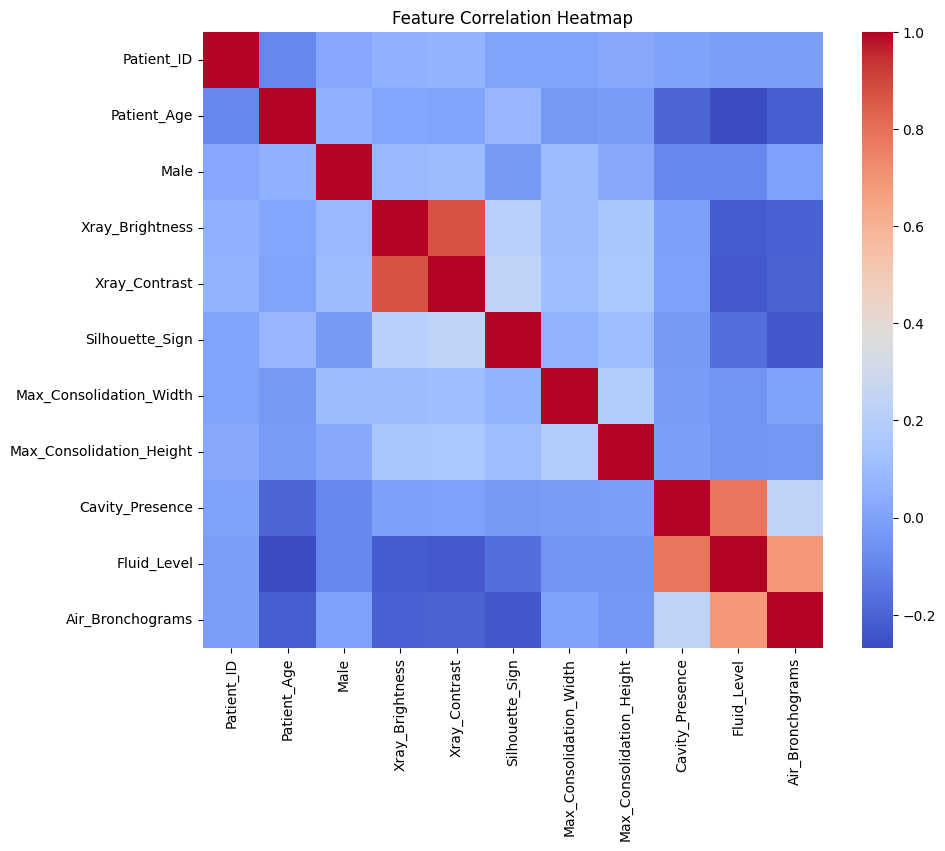

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features only
numeric_observations = observations.select_dtypes(include=['int64', 'Float64'])

# Create a correlation matrix
corr_matrix = numeric_observations.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


## Model 1 evaluation
 The following code cell evaluates a Decision Tree model. The resulting classification accuracy is **71.4%**.




**Investigation findings**

The `max_depth` hyperparameter has been investigated by evaluating the `Decision_Tree` model with depths ranging from 1 to 9. The model performed best at surface, 1, indicating that deeper trees overfit the data. Overrall the model performed competitively despite the limited depth.

In [ ]:
#import the packages we need
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#A list to hold the resulting accuracies
accuracies = []

#Create a decision tree classifier model object
model = DecisionTreeClassifier(random_state=99)

#Change the maximum tree depth
model.set_params(max_depth=1)

#Fit the model to our training data
model.fit(train_examples, train_labels)

#Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

#Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")


Accuracy: 0.7136752136752137 (or 71.4 %)


## Model 2 evaluation
The following code cell evaluates a k-Nearest Neighbours model. The resulting classification accuracy is **65.8%**.

**Investigation findings**  

For the KNN recipe, a pipeline was created combining k-NN with z-score standardisation to handle preprocessing steps. The number of  `n_neighbors` (hyperparameter) was thouroughly investigated using odd integers, from 1 to 9, to avoid ties in binary classifications (Stack Overflow, 2021).
The highest accuracy score was achieved with `k = 9`.

In [ ]:
#Import the packages we need
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

#set the name of target feature
target_feature = 'Pneumonia'

#fix typo error on observation #169 'np' instead of 'no'
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')

#split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
    stratify=labels
)
# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=9))])

# Fit the pipeline to our training data
pipeline.fit(train_examples, train_labels)

# Use the pipeline to generate predictions for our testing examples
predictions = pipeline.predict(test_examples)

#Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.6581196581196581 (or 65.8 %)


**Confusion Matrix on k-NN**

The following code cell evaluates a k- Nearest Neighbours model using a confusion matrix. This provides a detailed view of model performance by showing number of true positives, true negatives, false positives and false negatives.

Confusion Matrix:
[[  4  63]
 [  8 159]]


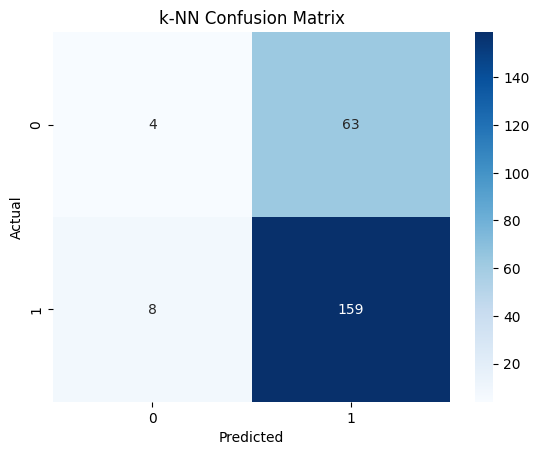

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(train_examples, train_labels)
knn_predictions = knn_model.predict(test_examples)

#Generate the confusion matrix
cm = confusion_matrix(test_labels, knn_predictions)
print("Confusion Matrix:")
print(cm)
#Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('k-NN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model 3 evaluation
The following code cell evaluates a Naive Bayes model. The resulting classification accuracy is **71.4%**.

**Investigation findings**

No hyperparameters available for Naive Bayes model that are supported by Scikit-learn. Overall the model performed competitively.

In [ ]:
#import the packages we need
from sklearn.naive_bayes import GaussianNB

#Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

#set the name of target feature
target_feature = 'Pneumonia'

#fix typo error on observation #169 'np' instead of 'no'
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')

#split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
    stratify=labels
)
#Create a Naive Bayes classification model object
model = GaussianNB()

#Fit the model to our training data
model.fit(train_examples, train_labels)

#Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

#Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7136752136752137 (or 71.4 %)


## Model 4 evaluation


 The following code cell evaluates a k-NN model using stratified k-fold cross validation. The resulting mean classificication accuracy is **69.0%**.


**Investigation findings**

In order for the model to perform a simple change to the recipe has been made. After thourough analysis of the '`pneumonia_raw`.csv' file, a typo error was found and a data cleaning step was performed to correct class label. After introducing stratified k-fold and cross validation, larger values of `n_neighbors` achieved higher accuracy. As a result, larger neighbourhood sizes reduce overfitting and perform more effectively when evaluated using `cross_validation`.   

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

#fix typo error on observation #169 'np' instead of 'no'
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a k-nearest neighbours classifier
model = KNeighborsClassifier(n_neighbors=9)

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

Average accuracy: 0.690 (or 69.0%)


# Model 5 evaluation

The following code cell evaluates an Artificial Neural Network classifier, MLPClassifier model. The resulting classification accuracy is **67.5%**

**Investigation Findings**

The ANN was evaluated achieving an accuracy of **67.5%**. Hyperparameters `hidden_layer_sizes` and `max_iter` were investigated to achieve the best performance.
optimization wasn't converged after reaching `max_iter` of 1000. By increasing `max_iter` to 3000 the optimization was converged. Overall the model did not outperform previous ones, indicating no real benefit to this model for this dataset.  

In [ ]:
from sklearn.neural_network import MLPClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

#fix typo error on observation #169 'np' instead of 'no'
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
    stratify=labels
)

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()),('ann', MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000, random_state=99))])

# Fit the model to our training data
pipeline.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = pipeline.predict(test_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.6752136752136753 (or 67.5 %)


# Conclusion on best performing model

Several classification model were investigated using a consistent basic recipe including data cleaning, stratified train test and preprocessing. Decision Tree and Naive Bayes achieved the highest performance, both reaching **71.4%**, while k-NN, SVC, and MLPClassifier achieved slightly lower accuracy.
DT model demonstrated good performance but can change noticeably if traning data changes slightly. NB model makes simplifying assumptions about the data which may not be accurate for this dataset.
Even though stratified k-fold cross-validation was performed on k-NN model its performance remained lower than the best performing models. An ANN was also evaluated, however it did not outperform other models.
Overall, Decision Tree and Naive Bayes are the best performing models

# Ensemble 1 evaluation

The following code cell evaluates a hard voting classifier ensemble composed of k-NN, Naive Bayes and Decision Tree. The resulting classification accuracy is **71.4%**.

**Investigation Findings**

The voting classifier ensemble achieved a **71.4%** accuracy matching the best individual models, Decision Tree and Naive Bayes, successfully maintaing consistent performance.

In [ ]:
#Import the packages we need
from sklearn.ensemble import VotingClassifier

#Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

#Set the name of the target feature
target_feature = 'Pneumonia'

#fix typo error on observation #169 'np' instead of 'no'
observations['Pneumonia'] = observations['Pneumonia'].replace('np', 'no')

#Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

#Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
    stratify=labels
)

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=7))])

#Set the details of the classifiers we want to use (using their best hyperparameter investigated in earlier code cells, DT only)
model2 = GaussianNB()
model3 = DecisionTreeClassifier(max_depth=1,random_state=99)

#Create a hard-voting ensemble composed of a k-NN, NB and DT classifier
model = VotingClassifier(estimators=[('knn', pipeline), ('nb', model2), ('dt', model3)], voting='hard')

#Fit the model to our training data
model.fit(train_examples, train_labels)

#Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

#Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7136752136752137 (or 71.4 %)


# Ensemble 2 evaluation

The following code cell evaluates a bagging classifier ensemble composed of 100 Decision Trees. The resulting classification accuracy is **74.4%**.
Overall, this ensemble outperformed RandomForest classifier.

In [ ]:
# Import the packages we need
from sklearn.ensemble import BaggingClassifier

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)
# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()),('dt', DecisionTreeClassifier(random_state=99))])

# Create a bagging ensemble classifier componsed of 100 DTs
model = BaggingClassifier(pipeline, n_estimators=100, random_state=99, bootstrap=False, max_features=2)

# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7435897435897436 (or 74.4 %)


# Ensemble 3 Evaluation

The following code cell evaluates a Random Forest Classifier. The resulting classification accuracy is **69.7%**.

**investigation findings**

The number of estimators was investigated with values of 10, 50, 100 and 200. Small values were avoided given that a Random Forest requires multiple trees to reduce variance. Investigation found that `n_estimator` perfomed best with value of 50.
To gain a comprehensive understanding of the model performance an ROC curve was used to see how well the model separates pneumonia cases from non pneumonia cases.


Accuracy: 0.6965811965811965 (or 69.7 %)


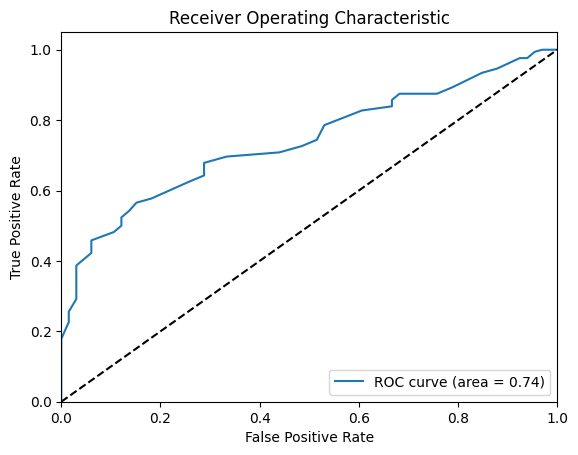

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a random forest classifier with its investigated hyperparameter
model = RandomForestClassifier(n_estimators=50, random_state=99)

# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

#ROC curve
# convert class labels yes/no to binary values
test_labels = np.where(test_labels == 'yes', 1, 0)

# Generate predicted probabilities for the positive class
y_prob = model.predict_proba(test_examples)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


# Task 2



> Colleague's claim: "*Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides*"



## Section 1: "We can classify the raw x-ray image data directly;"

While previous models performed reasonably well, they ultimately rely on manually extracted features, motivating an investigation towards colleague claim.

First aspect of the claim: The colleague claims that instead of manually extracting measurements from chest x-ray images, it is possible to classify the raw x-ray image data directly.


Yes, we can classify raw x-ray image data directly using deep  learning techniques, especially CNNs, Convolutional Neural Networks.

CNN is a type of learning algorithm designed specifically for tasks that need object recognition, Keita, Z. (2023).




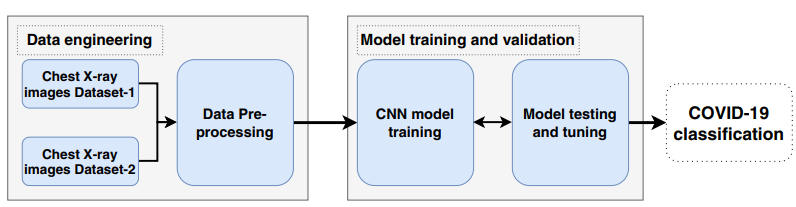

The above diagram, proposed by Madaan, V. et al. (2021), shows the end to end process of classifying raw chest x-ray images, specifically for COVID-19 detection, using Convolutional Neural Networks.

Other approaches suggestest the mixture of multiple convolution layers for feature extraction in conjuction with a Support Vector Machine classifier, SVM, for image classification. Below is a diagram for this proposed architecture by Almezhghwi, K., Serte, S. and Al-Turjman, F. (2021).

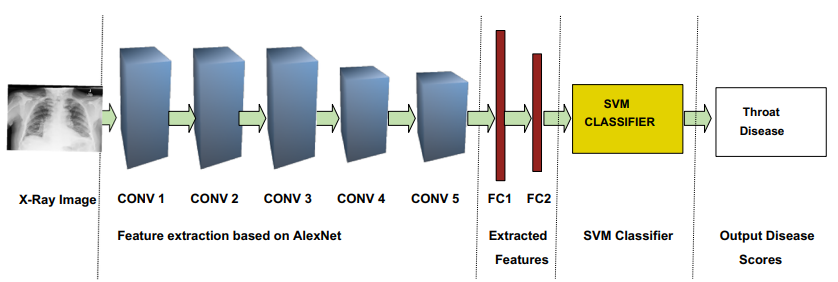

Furthermore, classifying raw chest x-ray images using machine learning is a well established technique within medical field, in particular using CNNs. Benefiting from AI may reduce the number of missed cases.

**Possible challenges**

Classifying raw chest x-ray images it is feasible, however, it does not imply simplicity.
CNN requires significal resources such as GPUs, a large dataset that is properly labelled, and may be liable to overfitting when dataset is not large enough (Tamanna, 2023), representing a technical and infrastructural burden.

## Section 2:  "it should be possible to get improved performance"

The second aspect: suggesting that it could possibly improve performance, save staff time.

A study proved that CNNs outperform humans. The comparison done by Man et al.(2019) using a lift curve, as shown in the image below, visualises the difference in performance between humans and CNNs, proving that CNNs outperform humans.

This can possibly lead to saving staff time.


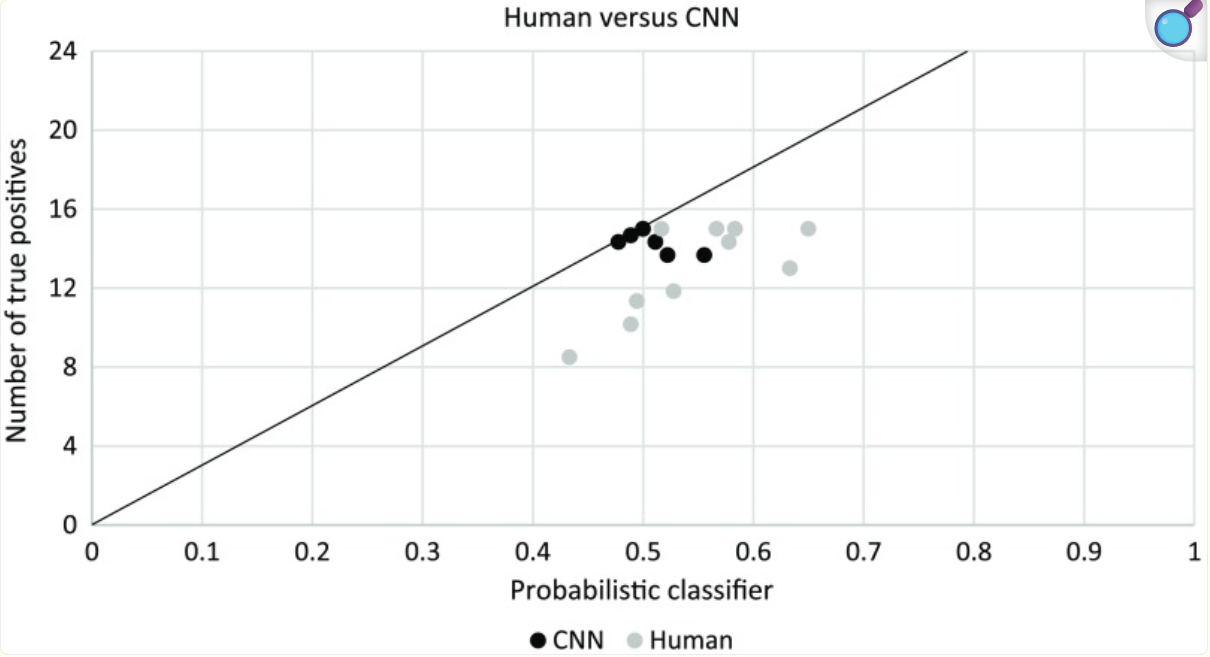

**Possible challenges**

The claim made by the colleague mentioning "improved performance" is partially supported.
This because CNN performance highly relies on large datasets. A small dataset will cause overfitting.


## Section 3: "and save on staff time"

Raw image classification may reduce staff time due to the automated measurements and feature extraction , however this claim does not consider the hidden labour of radiologists in labeling the training data (Morton, 2023).
Models development and maintenance often require specialised expertise, resulting in a workload shift rather than eliminating it completely.

Overall, statistical analysis conducted by Pucciarelli et al. (2025), as shown in the figure below, calculated the mean analysis time between AI models, experienced radiologists and radiology residents, proving that yes it can save time in the diagnosis process, but do not completely aid in saving medical staff time.

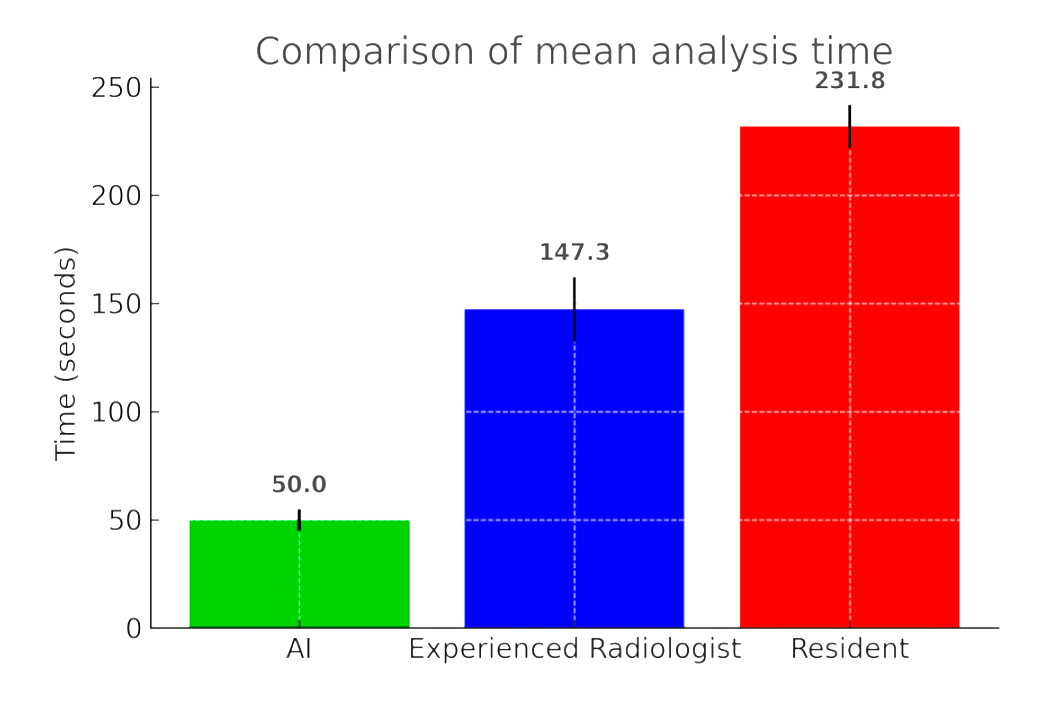

# Section 4: "without any downsides"

This aspect of the claim is classified as the weakest part of colleague claim. This because results from machine learning models may not be readable by every medical staff. If model performance provide different results it may be difficult for staff to notice this, as a result not everyone may be willing to accept the risk (Dhar, 2023).

Furthermore, noise, bias and variance are the three components in machine learning models that affect negatively performance (Koçak, et al. 2025).



# Section 5: Theory in practice

For this task i will be using a repository from Kaggle. The repository is made of chest X-ray images for Pneumonia detection, by Mooney (2018).

The CNN will follow Keras framework

In [ ]:
#import all the packages we need
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
import kagglehub

Download the latest version of Pneumonia image dataset and load data directly from repository by Mooney(2018).

In [ ]:
# Download latest version of image dataset from Kaggle
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Build the file path to the training and testing images

In [ ]:
#file path of kaggle repo for training image directory
train_path = os.path.join(path, 'chest_xray', 'train')

#file path of kaggle repo for testing image directory
test_path = os.path.join(path, 'chest_xray', 'test')

In [ ]:
#check we can see the dataset
os.path.exists(train_path)
os.path.exists(test_path)

True

**Data preparation**


Perform augmentations in the preprocessing steps.

 `ImageDataGenerator` pipeline will apply transformations to the image dataset (Walraven, 2019) on the parameters specified in the following recipe.
 Recipe from (McDermott, no date).

In [ ]:
#Image preprocessing steps
train_datagen = ImageDataGenerator(
    rescale=1./255, # normalise pixel values between 0-1
    validation_split=0.2  # split 20% of training images into validation, remaining 80% for training
)
test_datagen = ImageDataGenerator(rescale=1./255) # no split for testing data

#prepare training data
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128), #resize input images to not slow down performance as much this simple CNN
    batch_size=32, #process images in group of 32
    class_mode='binary', #two class classification 0 and 1
    subset='training' #use the 80% of image data defined earlier
)

#prepare validation data
validation_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128), #resize input images to not slow down performance as much this simple CNN
    batch_size=32, #process images in group of 32
    class_mode='binary', #two class classification 0 and 1
    subset='validation' #use the 20% of image data defined earlier
)

#prepare testing data
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128), #resize input images to not slow down performance as much this simple CNN
    batch_size=32, #process images in group of 32
    class_mode='binary' #two class classification 0 and 1
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


The preprocessing steps normalises and split image data without manual intervention, demonstrating that the colleague claim of classification of raw images can be performed.

# **Model architecture**

Define CNN architecture, composed of two convolutional layers to extract features from image dataset. Recipe from (Tamanna, 2023).

In [ ]:
#define the model architecture
model = Sequential()

#first layer
model.add(Conv2D(32, (3, 3), input_shape=(128, 128, 3))) #expect images of shape 128 x 128 with 3 colour channels
model.add(Activation('relu')) #introduce non linearity
model.add(MaxPooling2D(pool_size=(2, 2))) #reduce computation and overfitting

#second layer
model.add(Conv2D(64, (3, 3))) #expect images of shape 128 x 128 with 3 colour channels
model.add(Activation('relu')) #introduce non linearity
model.add(MaxPooling2D(pool_size=(2, 2))) #reduce computation and overfitting

#fully connected layer
model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))#introduce non linearity
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid')) #map values into value between 0 and 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The model architecture is composed by 2 convolutional layers that run in sequence.  `relu`, Rectified Linear Unit was introduced with formula, shown below, that removes negative values (Hazra, 2023).

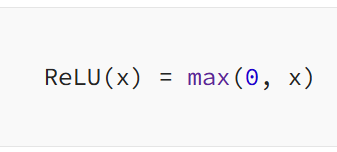

`MaxPooling2D` reduces the spacial size of input and keep the most important informations(Keras, no date)

It is possible to inspect the model architecture with `model.summary()`

In [ ]:
#inspect the architecture
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

**Compile**

In [ ]:
#compile the model
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])


# **Train the model**.

Training was intentionally limited. The recipe has been tuned to a  small number of `epochs`, which is the complete pass through all the training data (EdgeImpulse, no date), in this case 2 training cycles, to demonstrate the feasibility of colleague claim in a reasonable amount of time while keeping training phase manageable. Code recipe from (Devkota, 2026).

In [ ]:
#train the model
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=2,
    steps_per_epoch=100,
    validation_steps=20
)

#final evaluation on test data
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test accuracy: {test_accuracy:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7564 - loss: 0.7874 - val_accuracy: 0.9219 - val_loss: 0.1898
Epoch 2/2
 31/100 ━━━━━━━━━━━━━━━━━━━━ 1:11 1s/step - accuracy: 0.8733 - loss: 0.3169

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 781ms/step - accuracy: 0.8828 - loss: 0.2949 - val_accuracy: 0.9328 - val_loss: 0.1763
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 547ms/step - accuracy: 0.7114 - loss: 0.8291
Test accuracy: 0.702


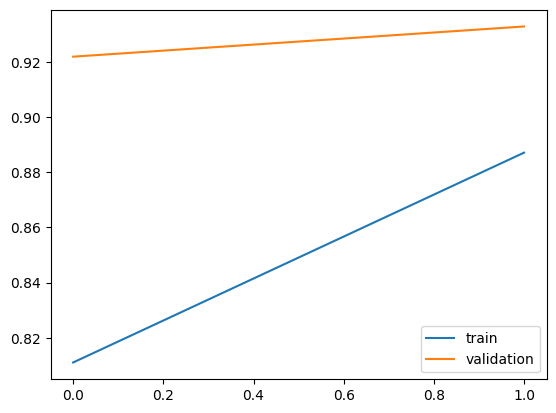

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()


**Model Output**

The CNN learned to classify x-ray images and achieved reasonable performance with a test accuracy of 75%, demonstrating the feasibility of raw x-ray image classification.

The first training cycle classified correctly around 75% of the training data, the second cycle improved performance than the previous classifying correctly around 90% of training data. The test accuracy percentage drop highlights the colleague claim, "without any downsides"  showing a substantial gap between training data and real world data.






...

# Conclusion


**Task 1**

 This investigation used a shuffled 60/40 train/test holdout split to evaluate the following models: `Decision Tree`, `k-NN`, `Naive Bayes`, and `MLPClassifier`. It found that the `Decision Tree` and `Naive Bayes` models gave the strongest performance with a classification accuracy of **71.4%**. `k-NN` model using stratified k-fold cross validation used a 80/20 train/test holdout split. The resulting mean classificication accuracy is **69.0%**. Hyperparameters of these models were thouroughly investigated to achieve the highest possible performance.
Other evaluation metrics were used such as Correlation Matrix to show relationships between input features, a confusion matrix on the `k-NN` model as well as ROC Curve on the `RandomForestClassifier` ensemble.

Task 1 was further investigated by evaluating the following ensembles: `VotingClassifier`, `BaggingClassifier` and `RandomForestClassifier`. It found that `BaggingClassifier` gave the strongest performance with a classification accuracy of **74.4%**.






**Task 2**

involved to critically analyse the colleague claim that classifying raw x-ray image data directly could improve performance, save staff time and introduce no downsides compared to manual measurement process. The task was investigated both theoretically and practically.
Results show that raw image classification is possible, as the CNN successfully learned patterns directly from x-ray images. Performance improved compared to models explored in task 1, supporting that deep learning can offer better performance.

The analysis supports the second part of the claim, saving staff time, since image classification removes the need for manual features extraction.

The third part of the claim, without any downsides, it is not supported. Limitations were identified during the investigation such as the reduced interpretability, reliance on large dataset and the risks of bias.

Overall the colleague claim it is partially correct. The claim should be pursued due to the clear advantages in performance, however, it will not fully reduce staff time.


# References

* Almezhghwi, K., Serte, S. and Al-Turjman,
F. (2021) “Convolutional neural networks for the classification of chest X-rays in the IoT era,” Multimedia Tools and Applications : An International Journal, 80(19), pp. 29051–29065. Available at: https://doi.org/10.1007/s11042-021-10907-y.

* De Man, R. et al. (2019) "Comparison of deep learning and human observer performance for detection and characterization of simulated lesion". Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC6586983/

* Dhar, T. et al. (2023) “Challenges of Deep Learning in Medical Image Analysis&#x2014;Improving Explainability and Trust,” IEEE Transactions on Technology and Society, 4(1). Available at: https://doi.org/10.1109/TTS.2023.3234203.

* Devkota, N. (2026) "Pneumonia Detection using CNN". Available at: https://www.kaggle.com/code/nojandevkota/pneumonia-detection-using-cnn/notebook

* EdgeImpulse, (no date) "Epochs". Available at: https://docs.edgeimpulse.com/knowledge/concepts/machine-learning/neural-networks/epochs

* Hazra, S. (2023) "Understanding ReLU Activation Function in Convolutional Neural Networks". Available at: https://medium.com/@sourenh94/understanding-relu-activation-function-in-convolutional-neural-networks-691614493bcb

* Keita, Z. (2023) "An Introduction to Convolutional Neural Networks (CNNs)" Available at: https://www.datacamp.com/tutorial/introduction-to-convolutional-neural-networks-cnns

* Keras (no date) "MaxPooling2D layer". Available at: https://keras.io/api/layers/pooling_layers/max_pooling2d/

* Koçak, B. et al. (2025) “Bias in artificial intelligence for medical imaging: fundamentals, detection, avoidance, mitigation, challenges, ethics, and prospects,” Diagnostic and interventional radiology (Ankara, Turkey), 31(2), pp. 75–88. Available at: https://doi.org/10.4274/dir.2024.242854.

* Madaan, V. et al. (2021) “XCOVNet: Chest X-ray Image Classification for COVID-19 Early Detection Using Convolutional Neural Networks,” New Generation Computing, 39(3-4), pp. 583–597. Available at: https://doi.org/10.1007/s00354-021-00121-7.

* McDermott, J. (no date) "Convolutional Neural Networks - Image Classification w. Keras". Available at: https://www.learndatasci.com/tutorials/convolutional-neural-networks-image-classification/

* Mooney, P. (2018) "Chest X-Ray Images (Pneumonia)". Available at: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data

* Morton, W. (2023) "Can 'normal filtering' AI save radiologists time?". Available at: https://www.auntminnie.com/imaging-informatics/artificial-intelligence/article/15659920/can-normal-filtering-ai-save-radiologists-time#:~:text=Will%20Morton,potentially%20significant%20number%20of%20reads.

* Pucciarelli, F. et al. (2025) "Evaluation of AI Performance in Spinal Radiographic Measurements Compared to Radiologists: A Study of Accuracy and Efficiency". Available at: https://www.mdpi.com/2313-433X/11/9/310

* Stack Overflow (2021)  "kNN and an even number of neighbors (k= 2, 4, 6, 8 ... and so on)".
Available at: https://stackoverflow.com/questions/69928483/knn-and-an-even-number-of-neighbors-k-2-4-6-8-and-so-on (Accessed: 13 december 2025).

* Tamanna (2023) "Convolutional Neural Networks - Architecture, Steps, Use Cases, and Pros and Cons". Available at: https://medium.com/@tam.tamanna18/exploring-convolutional-neural-networks-architecture-steps-use-cases-and-pros-and-cons-b0d3b7d46c71

* Walraven, B. (2019) "Boost your CNN with the Keras ImageDataGenerator". Available at: https://medium.com/@bcwalraven/boost-your-cnn-with-the-keras-imagedatagenerator-99b1ef262f47
